In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from kairos.data.loader import load_futures, METALS
from kairos.features.spread import bid_ask_spread, mid_price
from kairos.features.ofi import order_flow_imbalance
from kairos.features.vol import realized_vol
from kairos.models.lgbm import make_features, make_target, walk_forward_train

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

In [2]:
df = load_futures(METALS['gold'], period='1y', interval='1h')
print(f'Rows: {len(df)}')
print(f'Period: {df.timestamp.min()} → {df.timestamp.max()}')
df.head()

[*********************100%***********************]  1 of 1 completed

Rows: 5754
Period: 2025-03-27 12:00:00+00:00 → 2026-03-27 12:00:00+00:00


Price,timestamp,bid,ask,price,volume,side
0,2025-03-27 12:00:00+00:00,3055.300049,3064.600098,3058.100098,0,B
1,2025-03-27 13:00:00+00:00,3040.600098,3060.699951,3049.899902,15255,B
2,2025-03-27 14:00:00+00:00,3049.800049,3070.899902,3068.800049,10693,B
3,2025-03-27 15:00:00+00:00,3062.100098,3071.300049,3063.100098,14181,B
4,2025-03-27 16:00:00+00:00,3061.300049,3067.899902,3062.000000,8279,B


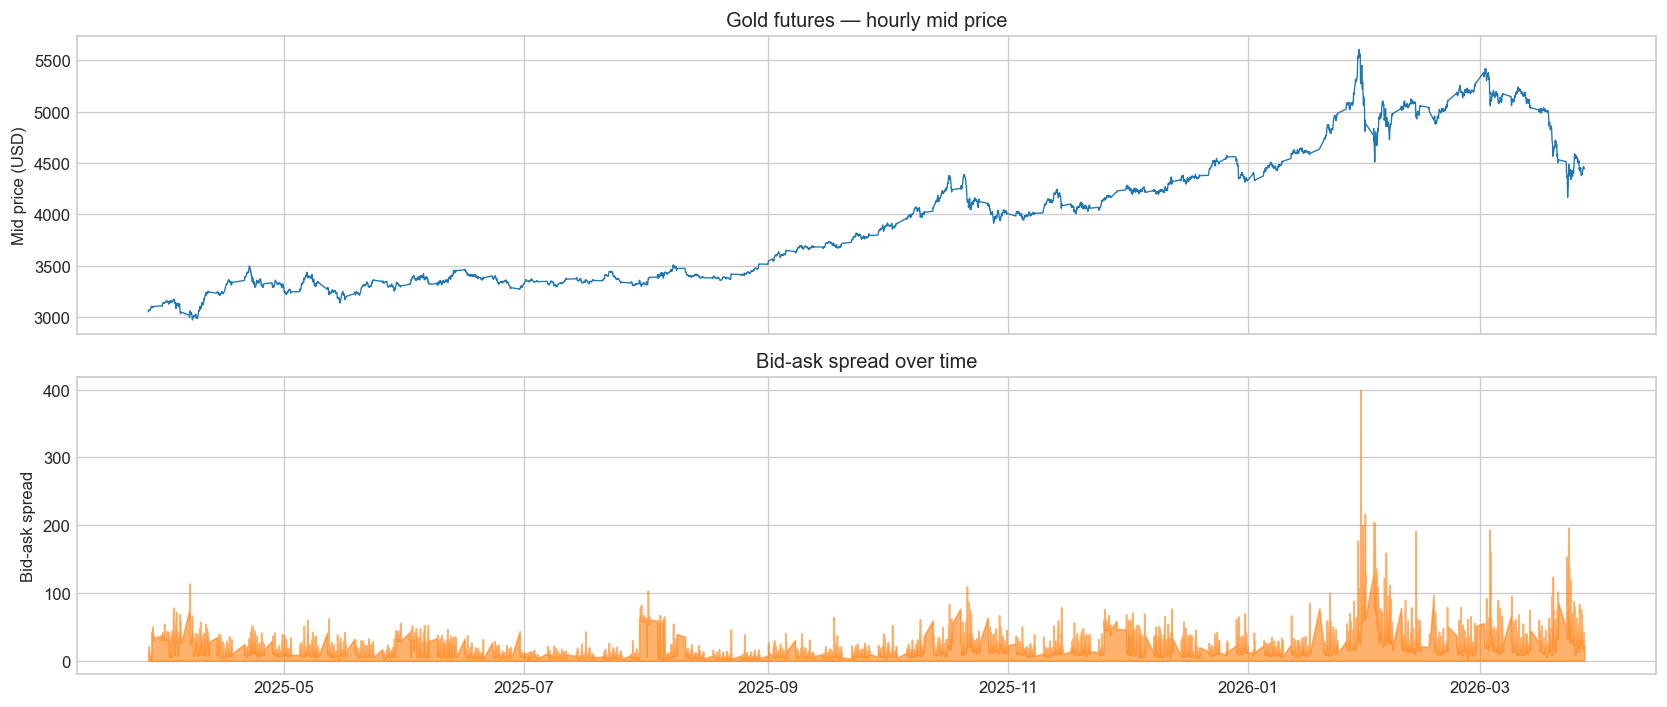

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

mid = mid_price(df)
axes[0].plot(df.timestamp, mid, linewidth=0.8, color='#1f77b4')
axes[0].set_ylabel('Mid price (USD)')
axes[0].set_title('Gold futures — hourly mid price')

spread = bid_ask_spread(df)
axes[1].fill_between(df.timestamp, spread, alpha=0.6, color='#ff7f0e')
axes[1].set_ylabel('Bid-ask spread')
axes[1].set_title('Bid-ask spread over time')

plt.tight_layout()
plt.show()

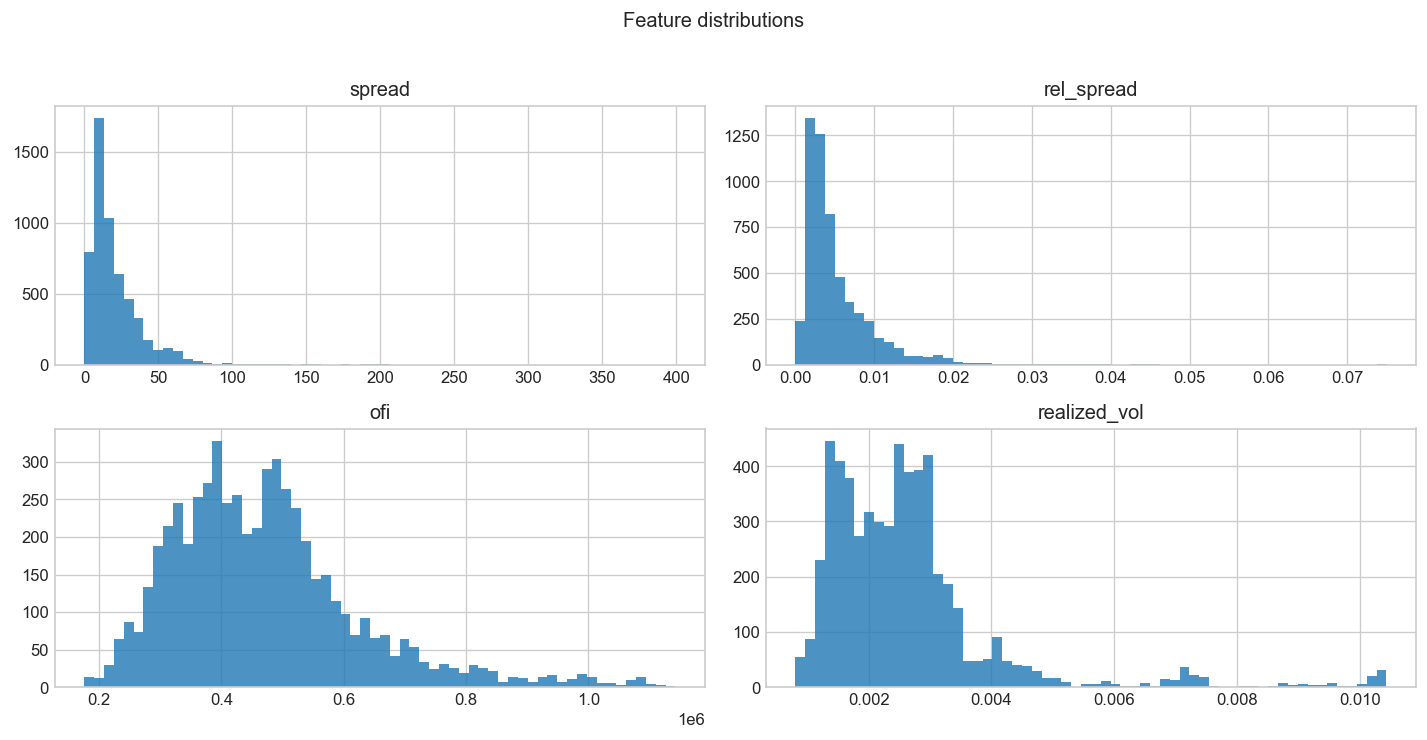

,spread,rel_spread,ofi,realized_vol
count,5654.0000,5654.0000,5.654000e+03,5654.0000
mean,21.2678,0.0053,4.712966e+05,0.0026
std,20.5571,0.0047,1.556651e+05,0.0015
min,0.0000,0.0000,1.760190e+05,0.0008
25%,8.7998,0.0024,3.644815e+05,0.0017
50%,14.7998,0.0037,4.513885e+05,0.0024
75%,27.2001,0.0066,5.403615e+05,0.0030
max,399.2998,0.0750,1.142165e+06,0.0104


In [4]:
feats = make_features(df).dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, col in zip(axes.flat, feats.columns):
    ax.hist(feats[col], bins=60, edgecolor='none', alpha=0.8)
    ax.set_title(col)

plt.suptitle('Feature distributions', y=1.02)
plt.tight_layout()
plt.show()

feats.describe().round(4)

[LightGBM] [Info] Number of positive: 498, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000348 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 942, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.528662 -> initscore=0.114776
[LightGBM] [Info] Start training from score 0.114776
[LightGBM] [Info] Number of positive: 973, number of negative: 911
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 1884, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.516454 -> initscore=0.065841
[LightGBM] [Info] 

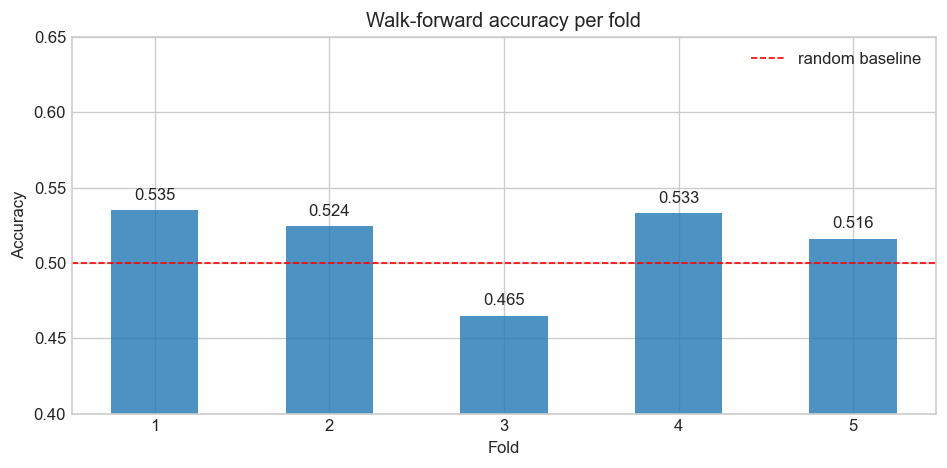

Mean accuracy: 0.515
Std:           0.026


In [5]:
results = walk_forward_train(df, n_splits=5)

folds = [r['fold'] for r in results]
accs  = [r['accuracy'] for r in results]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(folds, accs, color='#1f77b4', alpha=0.8, width=0.5)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='random baseline')
ax.set_ylim(0.4, 0.65)
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('Walk-forward accuracy per fold')
ax.legend()

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f'Mean accuracy: {np.mean(accs):.3f}')
print(f'Std:           {np.std(accs):.3f}')

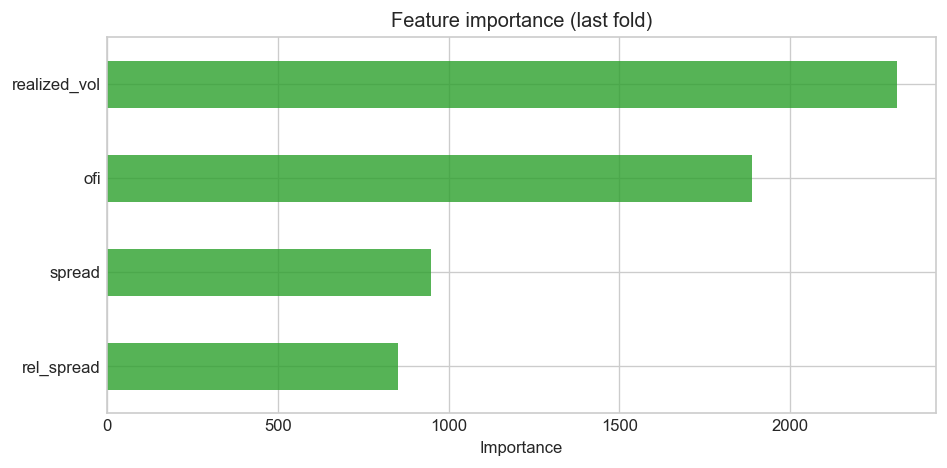

In [6]:
last_model = results[-1]['model']
X = make_features(df).dropna()

importance = pd.Series(
    last_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind='barh', ax=ax, color='#2ca02c', alpha=0.8)
ax.set_title('Feature importance (last fold)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()